# Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis

Student: Gyan Bahadur Tamang  
Course: MSCS 634 — Big Data and Data Mining  
Assignment: Lab 1  

This notebook analyzes a synthetic retail-sales dataset. A fixed seed makes the source reproducible; missing values and two extreme sales records are intentionally included to demonstrate preprocessing.

## Environment setup

Run this cell first. `%pip` installs packages into the same Python environment used by the current Jupyter kernel. If packages are newly installed, restart the kernel when prompted, then choose Run All.

In [13]:
%pip install -q pandas numpy matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 1: Data Collection

The retail-sales CSV is loaded into a Pandas DataFrame, and the first five rows are displayed with `.head()`.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
df = pd.read_csv('retail_sales_data.csv', parse_dates=['Date'])
df.head()

,Order_ID,Date,Region,Product,Units_Sold,Unit_Price,Discount,Customer_Satisfaction,Revenue
0,ORD-1001,2026-01-01,North,Laptop,6,973,0.00,3.3,5838.00
1,ORD-1002,2026-01-06,West,Tablet,12,481,0.05,3.5,5483.40
2,ORD-1003,2026-01-11,East,Phone,23,713,0.10,3.6,14759.10
3,ORD-1004,2026-01-16,South,Monitor,27,293,0.15,3.7,6724.35
4,ORD-1005,2026-01-21,North,Laptop,13,1013,0.00,3.7,13169.00


## Step 2: Data Visualization

The line plot aggregates revenue by month. Revenue rises sharply in April because one intentionally extreme order occurs then; this motivates outlier analysis.

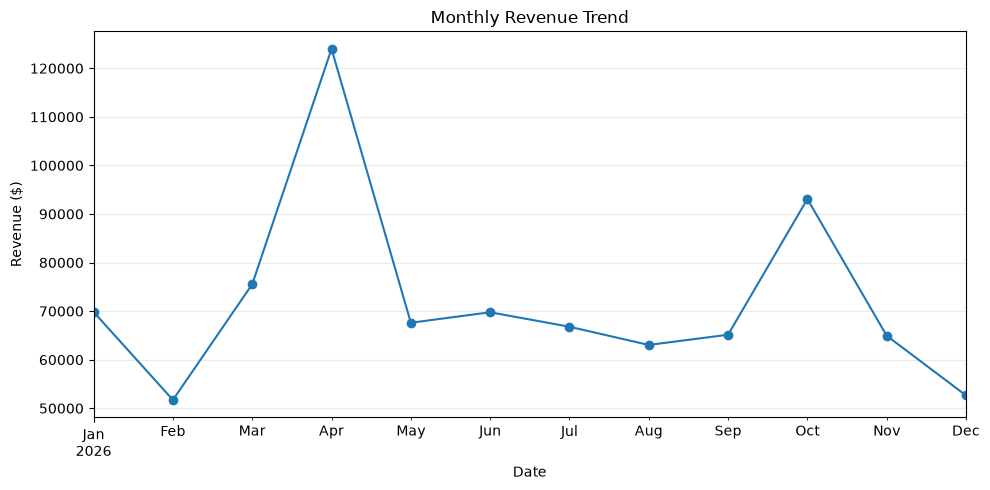

In [15]:
monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['Revenue'].sum()
monthly_revenue.plot(marker='o', figsize=(10,5), title='Monthly Revenue Trend')
plt.ylabel('Revenue ($)'); plt.grid(alpha=.25); plt.tight_layout()

The bar chart shows that laptops produce the most revenue despite equal product frequencies, largely because their unit price is highest. Product mix and price both matter when interpreting sales performance.

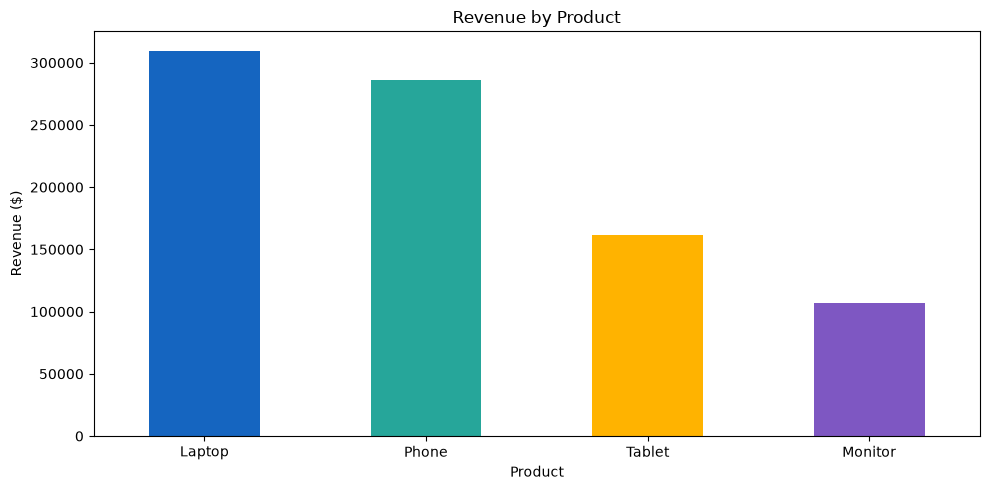

In [16]:
product_revenue = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
product_revenue.plot(kind='bar', color=['#1565C0','#26A69A','#FFB300','#7E57C2'], figsize=(10,5), title='Revenue by Product')
plt.ylabel('Revenue ($)'); plt.xticks(rotation=0); plt.tight_layout()

## Step 3: Data Preprocessing

### 1. Handling Missing Values
Numeric gaps are reported, then filled with column means. Mean imputation is suitable for this demonstration because only five values are missing; it preserves every sales record.

In [17]:
print('Missing values before:')
print(df.isna().sum())
print('\nRows with a missing value:')
display(df[df.isna().any(axis=1)])

clean_df = df.copy()
for col in ['Discount', 'Customer_Satisfaction']:
    clean_df[col] = clean_df[col].fillna(clean_df[col].mean())
print('\nMissing values after:')
print(clean_df.isna().sum())

Missing values before:
Order_ID                 0
Date                     0
Region                   0
Product                  0
Units_Sold               0
Unit_Price               0
Discount                 2
Customer_Satisfaction    3
Revenue                  0
dtype: int64

Rows with a missing value:


,Order_ID,Date,Region,Product,Units_Sold,Unit_Price,Discount,Customer_Satisfaction,Revenue
7,ORD-1008,2026-02-05,South,Monitor,7,336,0.15,NaN,1999.2
14,ORD-1015,2026-03-12,East,Phone,9,753,NaN,4.0,6099.3
31,ORD-1032,2026-06-05,South,Monitor,8,281,0.15,NaN,1910.8
47,ORD-1048,2026-08-24,South,Monitor,24,288,NaN,3.4,5875.2
60,ORD-1061,2026-10-28,North,Laptop,19,969,0.00,NaN,18411.0



Missing values after:
Order_ID                 0
Date                     0
Region                   0
Product                  0
Units_Sold               0
Unit_Price               0
Discount                 0
Customer_Satisfaction    0
Revenue                  0
dtype: int64


### 2. Outlier Detection and Removal
The 1.5×IQR rule is applied to `Units_Sold`. The two unusually large orders are removed for analyses where typical order behavior is the focus; the original DataFrame remains unchanged.

In [18]:
Q1 = clean_df['Units_Sold'].quantile(.25)
Q3 = clean_df['Units_Sold'].quantile(.75)
IQR = Q3-Q1
lower, upper = Q1-1.5IQR, Q3+1.5IQR
outliers = clean_df[(clean_df.Units_Sold < lower)|(clean_df.Units_Sold > upper)]
filtered_df = clean_df[clean_df.Units_Sold.between(lower, upper)].copy()
print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, bounds=({lower:.2f}, {upper:.2f})')
display(outliers)
print('After removal:', filtered_df.shape)

Q1=13.00, Q3=25.00, IQR=12.00, bounds=(-5.00, 43.00)


,Order_ID,Date,Region,Product,Units_Sold,Unit_Price,Discount,Customer_Satisfaction,Revenue
18,ORD-1019,2026-04-01,East,Phone,105,703,0.10,3.1,66433.5
55,ORD-1056,2026-10-03,South,Monitor,92,314,0.15,3.5,24554.8


After removal: (70, 9)


### 3. Data Reduction
Identifier, discount, and satisfaction fields are dropped for a compact sales view, then a reproducible 20% sample is selected.

In [19]:
print('Before:', filtered_df.shape, filtered_df.columns.tolist())
reduced_df = filtered_df.drop(columns=['Order_ID','Discount','Customer_Satisfaction']).sample(frac=.20, random_state=634)
print('After:', reduced_df.shape, reduced_df.columns.tolist())
reduced_df.head()

Before: (70, 9) ['Order_ID', 'Date', 'Region', 'Product', 'Units_Sold', 'Unit_Price', 'Discount', 'Customer_Satisfaction', 'Revenue']
After: (14, 6) ['Date', 'Region', 'Product', 'Units_Sold', 'Unit_Price', 'Revenue']


,Date,Region,Product,Units_Sold,Unit_Price,Revenue
21,2026-04-16,West,Tablet,13,462,5705.7
50,2026-09-08,East,Phone,22,738,14612.4
69,2026-12-12,West,Tablet,8,486,3693.6
22,2026-04-21,East,Phone,18,743,12036.6
30,2026-05-31,East,Phone,23,716,14821.2


### 4. Data Scaling and Discretization
Min–Max scaling maps units to [0,1]; Z-scores express distance from the mean in standard deviations. Business-friendly bands discretize order size.

In [20]:
scaled_df = filtered_df[['Units_Sold']].copy()
u=scaled_df.Units_Sold
scaled_df['MinMax_Units']=(u-u.min())/(u.max()-u.min())
scaled_df['ZScore_Units']=(u-u.mean())/u.std()
scaled_df['Sales_Band']=pd.cut(u, bins=[-np.inf,15,25,np.inf], labels=['Low','Medium','High'])
scaled_df.head(7)

,Units_Sold,MinMax_Units,ZScore_Units,Sales_Band
0,6,0.000000,-1.902444,Low
1,12,0.250000,-1.025357,Low
2,23,0.708333,0.582636,Medium
3,27,0.875000,1.167361,High
4,13,0.291667,-0.879175,Low
5,20,0.583333,0.144093,Medium
6,23,0.708333,0.582636,Medium


## Step 4: Statistical Analysis

### 1. General Overview of Data

In [21]:
df.info()
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Order_ID               72 non-null     str           
 1   Date                   72 non-null     datetime64[us]
 2   Region                 72 non-null     str           
 3   Product                72 non-null     str           
 4   Units_Sold             72 non-null     int64         
 5   Unit_Price             72 non-null     int64         
 6   Discount               70 non-null     float64       
 7   Customer_Satisfaction  69 non-null     float64       
 8   Revenue                72 non-null     float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 5.2 KB


,Date,Units_Sold,Unit_Price,Discount,Customer_Satisfaction,Revenue
count,72,72.000000,72.000000,70.000000,69.000000,72.000000
mean,2026-06-27 12:00:00,21.222222,619.222222,0.073571,3.897101,12000.579861
min,2026-01-01 00:00:00,6.000000,281.000000,0.000000,3.000000,1910.800000
25%,2026-03-30 18:00:00,13.000000,405.250000,0.012500,3.500000,5849.325000
50%,2026-06-27 12:00:00,19.000000,588.500000,0.050000,3.900000,10534.925000
75%,2026-09-24 06:00:00,25.000000,801.500000,0.100000,4.300000,15435.975000
max,2026-12-22 00:00:00,105.000000,1013.000000,0.150000,4.800000,66433.500000
std,NaN,14.822159,255.797963,0.056287,0.470285,9201.056508


### 2. Central Tendency Measures

In [22]:
numeric = clean_df.select_dtypes(include='number')
central = pd.DataFrame({'Minimum':numeric.min(),'Maximum':numeric.max(),'Mean':numeric.mean(),'Median':numeric.median(),'Mode':numeric.mode().iloc[0]})
central

,Minimum,Maximum,Mean,Median,Mode
Units_Sold,6.0,105.00,21.222222,19.000000,18.0
Unit_Price,281.0,1013.00,619.222222,588.500000,313.0
Discount,0.0,0.15,0.073571,0.061786,0.0
Customer_Satisfaction,3.0,4.80,3.897101,3.900000,4.4
Revenue,1910.8,66433.50,12000.579861,10534.925000,1910.8


### 3. Dispersion Measures

In [23]:
dispersion = pd.DataFrame({'Range':numeric.max()-numeric.min(),'Q1':numeric.quantile(.25),'Q2':numeric.quantile(.50),'Q3':numeric.quantile(.75),'IQR':numeric.quantile(.75)-numeric.quantile(.25),'Variance':numeric.var(),'Std_Dev':numeric.std()})
dispersion

,Range,Q1,Q2,Q3,IQR,Variance,Std_Dev
Units_Sold,99.00,13.0000,19.000000,25.000,12.0000,2.196964e+02,14.822159
Unit_Price,732.00,405.2500,588.500000,801.500,396.2500,6.543260e+04,255.797963
Discount,0.15,0.0375,0.061786,0.100,0.0625,3.078974e-03,0.055489
Customer_Satisfaction,1.80,3.5750,3.900000,4.300,0.7250,2.118228e-01,0.460242
Revenue,64522.70,5849.3250,10534.925000,15435.975,9586.6500,8.465944e+07,9201.056508


### 4. Correlation Analysis
Revenue is strongly associated with both units sold and unit price. Correlation describes association, not causation; the calculation also includes the deliberately extreme orders.

In [24]:
correlation_matrix = numeric.corr()
correlation_matrix

,Units_Sold,Unit_Price,Discount,Customer_Satisfaction,Revenue
Units_Sold,1.000000,-0.085323,0.145745,-0.173160,0.761119
Unit_Price,-0.085323,1.000000,-0.754315,-0.018994,0.489236
Discount,0.145745,-0.754315,1.000000,0.046909,-0.315985
Customer_Satisfaction,-0.173160,-0.018994,0.046909,1.000000,-0.163885
Revenue,0.761119,0.489236,-0.315985,-0.163885,1.000000
